# The Magnus Archives: Linguistic Analysis of Fear

**Main objective:** This project conducts a comprehensive quantitative and qualitative analysis of transcripts from the horror podcast "The Magnus Archives" to identify the dynamics of character appearances, lexical features of the narrative, and contextual patterns associated with key plot figures across all five seasons.

## 1. Импорт библиотек и настройка

In [66]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.text import Text
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from math import pi
import os

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

os.makedirs('plots', exist_ok=True)

## 2. Data Extraction and Parsing

Getting the texts of the episodes from the .txt files and compiling the data into one dictionary

In [67]:
def episodes(season_data):
    season_episodes = []
    for line in season_data:
        if line.startswith("MAG") and not line.startswith("MAGNUS"):
            season_episodes.append(line)
    return season_episodes

def content(season_data, season_episodes):
    season = {}
    for episode in season_episodes:
        current_episode = None
        new_episode_data = []
        for line in season_data:
            if line in season_episodes:
                current_episode = line
            if current_episode == episode:
                if line != episode:
                    line = re.sub(r'[^\w\s]', ' ', line.lower())
                    new_episode_data.append(line)
        new_episode_data = ' '.join(new_episode_data)
        new_episode_data = re.sub(r'\s+', ' ', new_episode_data)
        season[episode] = new_episode_data
    return season

def tma_season(file):
    with open(file, mode='r', encoding='utf-8') as infile:
        season_data = []
        for line in infile:
            if line.strip() != '':
                season_data.append(line.strip())
        season_episodes = episodes(season_data)
        season = content(season_data, season_episodes)
    return season

seasons = [tma_season(f'the_magnus_archives_season_{i + 1}.txt') for i in range(5)]
print(f"Downloaded {len(seasons)} seasons")
for i, season in enumerate(seasons):
    print(f"  Season {i+1}: {len(season)} episodes")

Downloaded 5 seasons
  Season 1: 43 episodes
  Season 2: 41 episodes
  Season 3: 41 episodes
  Season 4: 41 episodes
  Season 5: 42 episodes


## 3. Text Normalization

Getting the texts lemmanized and tokenized for easier analysis later.

In [78]:
def lemmas(text):
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    cleaned = [token for token in tokens if token.isalpha() and token not in stop_words]
    return cleaned

def lemmanisation(season):
    all_lemmas = []
    for episode in season:
        text = season[episode]
        lems = lemmas(text)
        all_lemmas.extend(lems)
    return all_lemmas

def count_most_common(grams):
    all_grams_counted = Counter(grams)
    return all_grams_counted.most_common()

In [79]:
lemmed_texts = {}
all_lemmas = []

for i in range(5):
    lems = lemmanisation(seasons[i])
    all_lemmas += lems
    lemmed_texts[f"Season {i + 1}"] = " ".join(lems)
    print(f"  Season {i+1}: {len(lems)} lemmas")

print(f"\nTotal lemmas: {len(all_lemmas)}")

  Season 1: 65688 lemmas
  Season 2: 62426 lemmas
  Season 3: 62555 lemmas
  Season 4: 65026 lemmas
  Season 5: 64284 lemmas

Total lemmas: 319979


## 5. TF-IDF Analysis

Identifying distinctive vocabulary for each season, getting the most important words for each season.

In [80]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(lemmed_texts.values())

print("\nTF-IDF Top Words per Season:")
print("-" * 50)

top_words_per_season = {}

for idx, (name, text) in enumerate(lemmed_texts.items()):
    tfidf_scores = tfidf_matrix.toarray()[idx]
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    sorted_indices = tfidf_scores.argsort()[-30:][::-1]
    top_words = [(feature_names[i], tfidf_scores[i]) for i in sorted_indices]
    top_words_per_season[name] = top_words
    
    print(f"\n{name}:")
    for word, score in top_words[:10]:
        print(f"  {word}: {score:.4f}")


TF-IDF Top Words per Season:
--------------------------------------------------

Season 1:
  like: 0.2032
  one: 0.1908
  could: 0.1881
  archivist: 0.1877
  know: 0.1784
  time: 0.1673
  though: 0.1620
  statement: 0.1589
  would: 0.1416
  see: 0.1368

Season 2:
  archivist: 0.2730
  like: 0.2372
  one: 0.1982
  could: 0.1836
  know: 0.1718
  would: 0.1624
  even: 0.1469
  time: 0.1459
  back: 0.1450
  though: 0.1384

Season 3:
  archivist: 0.4040
  know: 0.2542
  like: 0.2123
  martin: 0.2096
  one: 0.1653
  elias: 0.1556
  think: 0.1417
  would: 0.1362
  tim: 0.1308
  daisy: 0.1253

Season 4:
  archivist: 0.4314
  basira: 0.2677
  know: 0.2308
  martin: 0.2213
  like: 0.1988
  one: 0.1667
  would: 0.1416
  could: 0.1387
  daisy: 0.1278
  well: 0.1147

Season 5:
  martin: 0.5910
  archivist: 0.5646
  know: 0.1624
  basira: 0.1463
  like: 0.1432
  one: 0.0933
  oh: 0.0902
  right: 0.0879
  see: 0.0856
  would: 0.0817


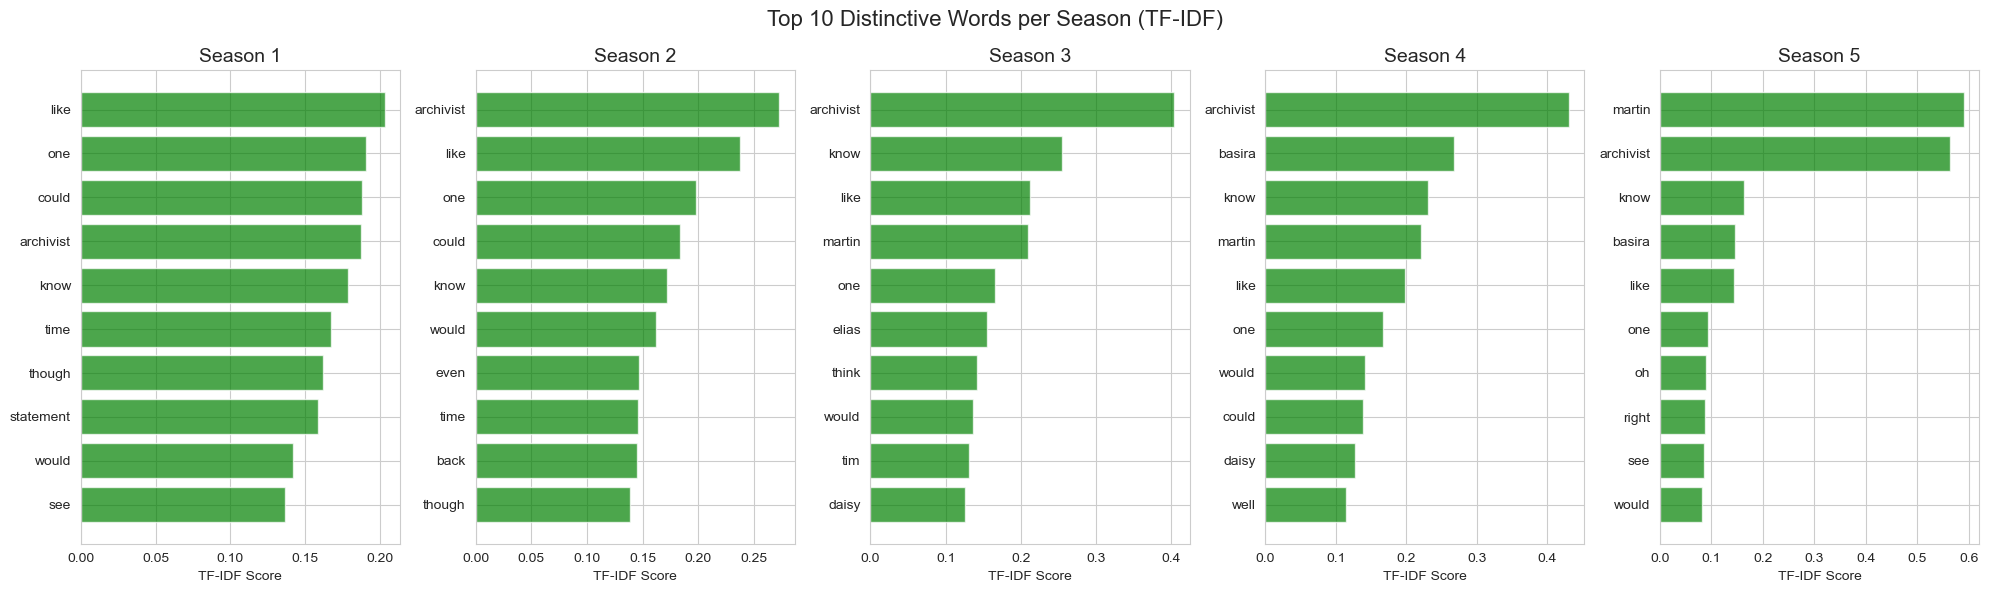

In [82]:
# Visualising the results

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for idx, (season, words) in enumerate(top_words_per_season.items()):
    top_10 = words[:10]
    words_list, scores = zip(*top_10)
    
    axes[idx].barh(words_list, scores, color='green', alpha=0.7)
    axes[idx].set_title(season, fontsize=14)
    axes[idx].set_xlabel('TF-IDF Score')
    axes[idx].invert_yaxis()

plt.suptitle('Top 10 Distinctive Words per Season (TF-IDF)', fontsize=16)
plt.tight_layout()

plt.show()

## 6. Analizing the Fears

From the wikia:

The Entities, also called the Fears, the Powers, the Dread Powers, and The Things That Were Fear are the principle antagonists of The Magnus Archives, and the phenomena that more mundane and earthly antagonists serve.

They are various aspects of an amorphous force of fear that exists next to reality. They are variously also referred to as "Gods", "powers", or simply as "the Fears". Their influence upon reality manifests as supernatural happenings — all supernatural phenomena in the world are simply extensions of them. These phenomena can take various forms such as people, animals, monsters, books, objects, or places, all with the goal of evoking fear, terror, and paranoia from all who encounter them.

These entities do not simply feed off of fear but are fears made manifest. It is not only human fear that counts but that of animals as well, particularly for The Flesh and The Hunt. The more fearful the world is of a certain thing, the more powerful the related entity becomes, becoming empowered by the increased fear of its realm of influence.

**Hypothesis:** Which Fear is the most prominent changes from season to season. From knowing the plot (the Prentiss attack, stopping the Unkowing, the arrival of Peter Lukas, the Eyepocalypse) one can expect the following results:

*Corruption* being the most prominent for Seasons 1 and 2
*Stranger* being the most prominent for Season 3
*Lonely* being the most prominent for Season 4
*Eye* being the most important in Season 5, being strong in all seasons

In [83]:
fears = {
    'The Eye': ['record', 'witness', 'observe', 'document', 'truth', 'vision', 'knowing', 'beholding', 'gaze', 'eye', 'watch'],
    'The Web': ['spider', 'web', 'thread', 'manipulate', 'control', 'plan', 'trap', 'scheme', 'puppet', 'string'],
    'The Buried': ['buried', 'earth', 'dirt', 'claustrophobic', 'suffocate', 'crush', 'pressure', 'deep', 'underground', 'grave'],
    'The Vast': ['vast', 'sky', 'height', 'open', 'ocean', 'space', 'depth', 'fall', 'expanse', 'void', 'infinite'],
    'The Flesh': ['flesh', 'meat', 'animal', 'bone', 'slaughter', 'butcher', 'body', 'skin', 'muscle', 'carnage', 'blood'],
    'The Lonely': ['lonely', 'alone', 'abandoned', 'empty', 'forgotten', 'fog', 'mist', 'isolated', 'solitude', 'apart', 'cold'],
    'The Spiral': ['spiral', 'madness', 'insane', 'crazy', 'distortion', 'mind', 'dream', 'unreliable', 'hallucination', 'fractal'],
    'The Stranger': ['stranger', 'unknown', 'unfamiliar', 'mask', 'mannequin', 'circus', 'skin', 'identity', 'uncanny', 'doll'],
    'The Corruption': ['worm', 'wasp', 'corruption', 'rot', 'decay', 'mold', 'infection', 'disease', 'filth', 'contaminate', 'insect', 'maggot'],
    'The Desolation': ['desolation', 'fire', 'burn', 'destroy', 'devastation', 'ash', 'flame', 'scorch'],
    'The Slaughter': ['slaughter', 'war', 'violence', 'kill', 'murder', 'massacre', 'carnage', 'combat', 'battle', 'bullet'],
    'The End': ['death', 'die', 'mortal', 'final', 'grave', 'coffin', 'terminal', 'mortality', 'expire', 'dead'],
    'The Dark': ['dark', 'darkness', 'shadow', 'lightless', 'blind', 'night', 'black', 'obscure', 'gloom'],
    'The Hunt': ['hunt', 'hunter', 'prey', 'pursue', 'track', 'fang', 'beast', 'predator', 'chase', 'wild']
}

def count_fear_mentions(seasons, fears):
    fear_counts = {}
    
    for fear, keywords in fears.items():
        fear_counts[fear] = []
        for i in range(5):
            season_text = ' '.join(seasons[i].values()).lower()
            count = sum(season_text.count(keyword) for keyword in keywords)
            total_words = len(season_text.split())
            normalized = count / total_words * 10000 if total_words > 0 else 0
            fear_counts[fear].append(normalized)
    
    return fear_counts

fear_counts = count_fear_mentions(seasons, fears)
fear_df = pd.DataFrame(fear_counts, index=['Season 1', 'Season 2', 'Season 3', 'Season 4', 'Season 5'])

print("Fear frequency per season (mentions per 10,000 words):")
print("-" * 60)
print(fear_df.round(2))

Fear frequency per season (mentions per 10,000 words):
------------------------------------------------------------
          The Eye  The Web  The Buried  The Vast  The Flesh  The Lonely  \
Season 1    34.49    11.27       10.79     22.40      27.59       16.53   
Season 2    36.76    13.37       11.04     24.70      24.34       14.38   
Season 3    35.67    12.55       11.96     21.74      24.87       12.91   
Season 4    29.65    19.74       14.15     22.08      21.51       16.63   
Season 5    31.83    19.50       14.57     22.12      26.60       13.82   

          The Spiral  The Stranger  The Corruption  The Desolation  \
Season 1       11.13          9.70           12.50           25.20   
Season 2       12.13          8.50           11.62           22.81   
Season 3       12.62         15.61            8.90           17.43   
Season 4       12.03          5.52            6.30           15.57   
Season 5       10.69          9.19           10.98           26.53   

          Th

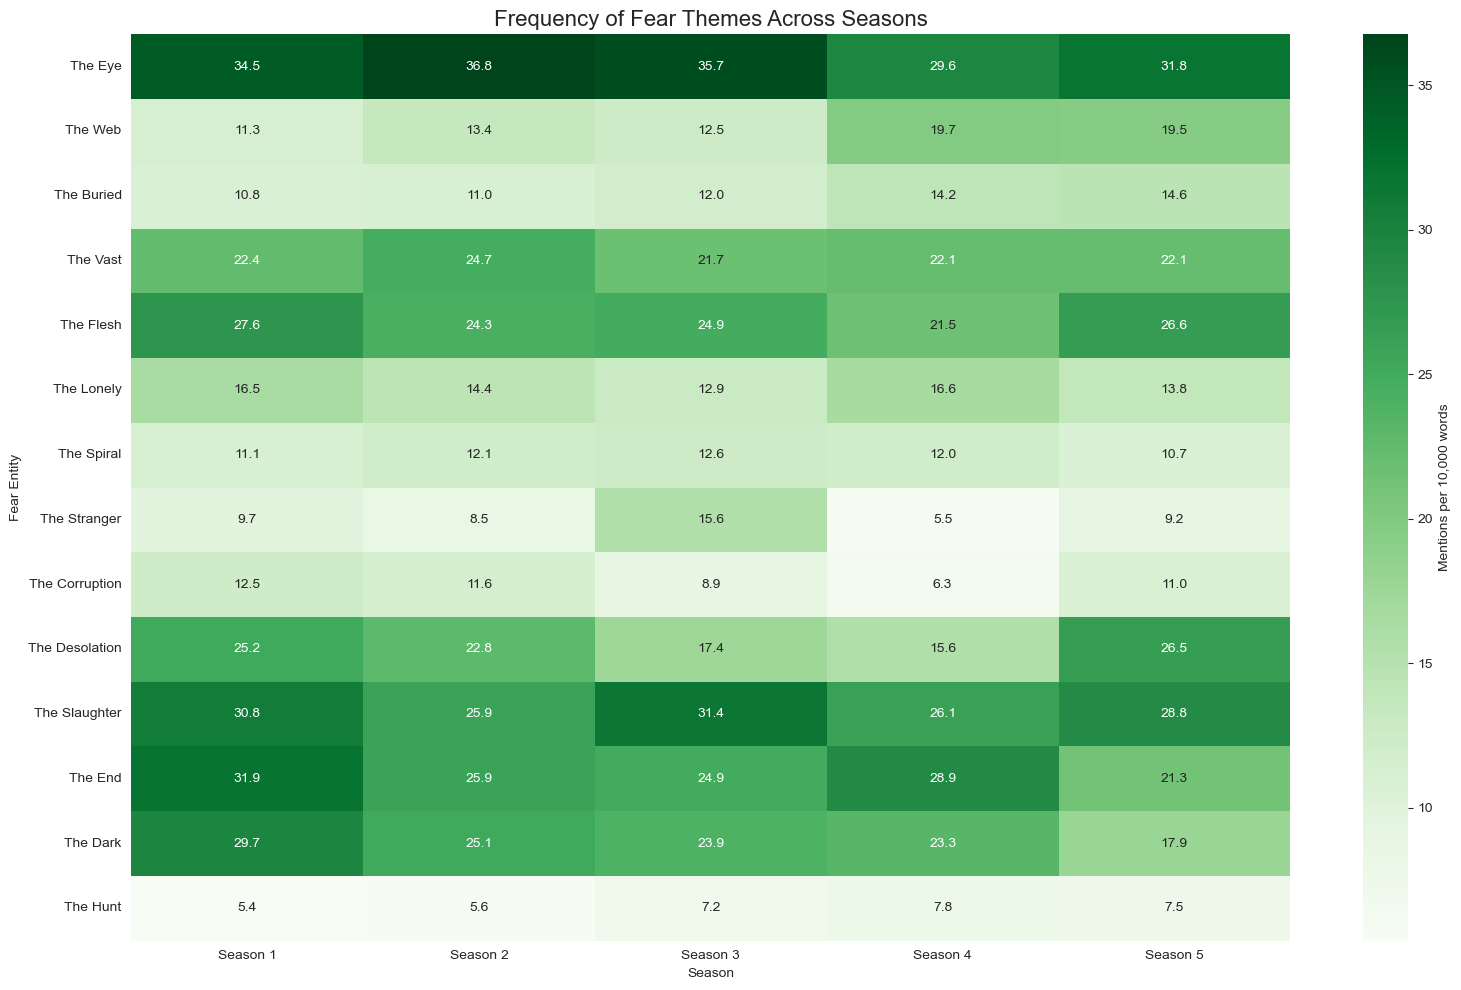

In [84]:
# Building the Heat map. The Fears map?

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(fear_df.T, annot=True, fmt='.1f', cmap='Greens',
            cbar_kws={'label': 'Mentions per 10,000 words'}, ax=ax)
ax.set_title('Frequency of Fear Themes Across Seasons', fontsize=16)
ax.set_xlabel('Season')
ax.set_ylabel('Fear Entity')
plt.tight_layout()

plt.show()

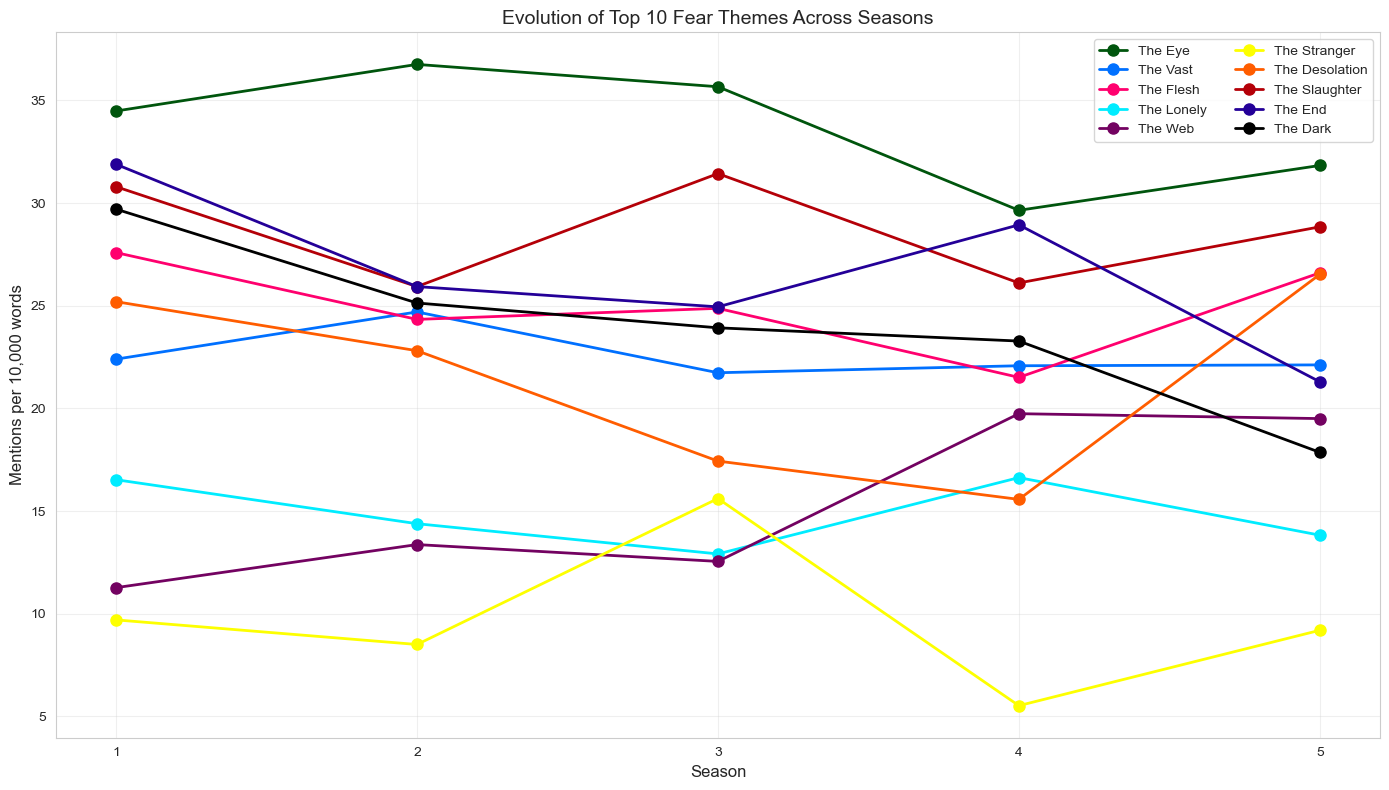

In [85]:
# Top-10 Fears
top_fears = ['The Eye', 'The Vast', 'The Flesh', 'The Lonely', 'The Web', 'The Stranger', 'The Desolation', 'The Slaughter', 'The End', 'The Dark']

fig, ax = plt.subplots(figsize=(14, 8))

colors = [
    '#00550d',  # The Eye - dark green
    '#0070ff',  # The Vast - blue
    '#ff006e',  # The Flesh - reddish pink
    '#00ecff',  # The Lonely - cyan
    '#730261',  # The Web - dark purple
    '#fdff00',  # The Stranger - yellow
    '#ff5d00',  # The Desolation - red-orange
    '#b40008',  # The Slaughter - red
    '#240098',  # The End - dark blue
    '#000000'   # The Dark - black
]

# Plot all 10 Fears
for fear, color in zip(top_fears, colors):
    ax.plot(range(1, 6), fear_counts[fear], marker='o', label=fear, 
            linewidth=2, color=color, markersize=8)

ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Mentions per 10,000 words', fontsize=12)
ax.set_title('Evolution of Top 10 Fear Themes Across Seasons', fontsize=14)
ax.legend(loc='best', ncol=2)  # 2 columns for cleaner layout
ax.grid(alpha=0.3)
ax.set_xticks(range(1, 6))
plt.tight_layout()

plt.show()


## 7. The Eye Index

With The Magnus Institute as a whole being a temple of the Eye, with the Eyepocalypse happening in the finale and with Jon being an avatar of the Eye, the Eye is the most prominent of all the Fears as seen above. 

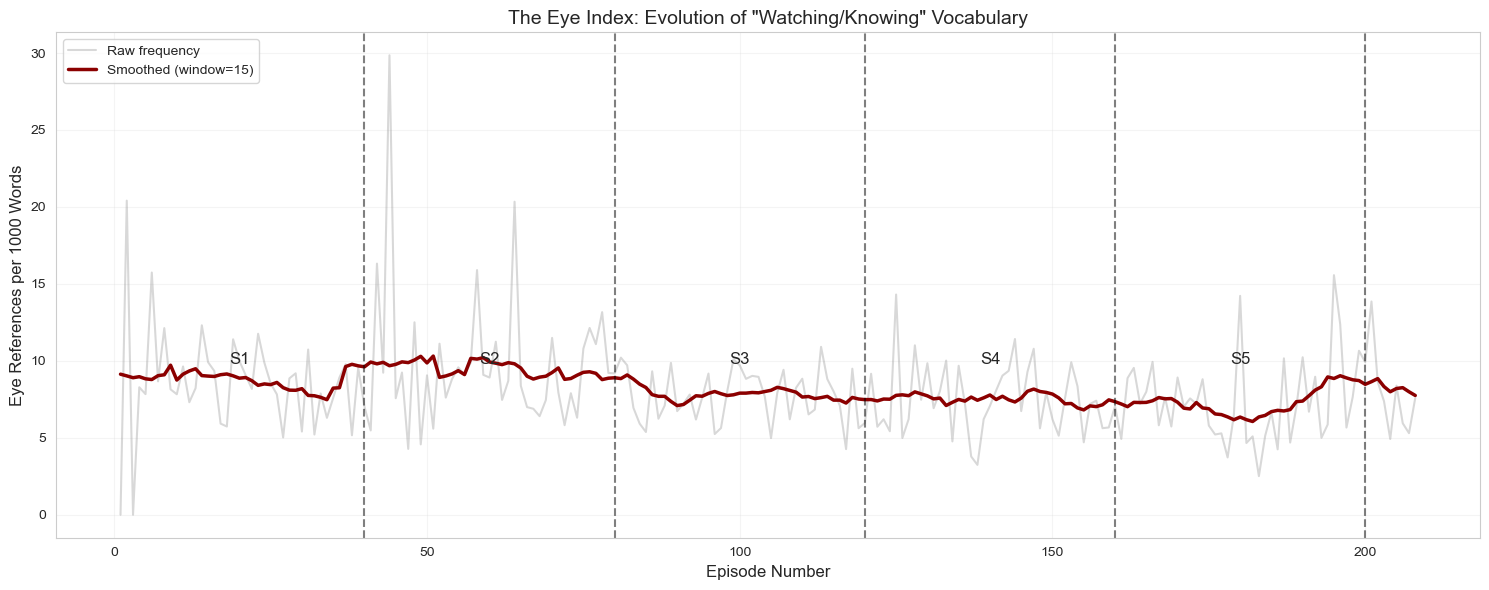

In [86]:
def calculate_eye_index(seasons, eye_keywords):
    eye_index = []
    episode_counter = 0
    
    for season_idx, season in enumerate(seasons):
        for episode in season:
            episode_counter += 1
            text = season[episode].lower()
            count = sum(text.count(word) for word in eye_keywords)
            total_words = len(text.split())
            normalized = count / total_words * 1000 if total_words > 0 else 0
            eye_index.append((episode_counter, normalized))
    
    return eye_index

def moving_average(data, window=10):
    smoothed = []
    for i in range(len(data)):
        start = max(0, i - window // 2)
        end = min(len(data), i + window // 2 + 1)
        smoothed.append(sum(data[start:end]) / (end - start))
    return smoothed

eye_keywords = ['record', 'witness', 'observe', 'document', 'truth', 'vision', 'knowing', 'beholding', 'gaze', 'eye', 'watch', 'see']

eye_data = calculate_eye_index(seasons, eye_keywords)
episodes_list, values = zip(*eye_data)
smoothed = moving_average(values, window=15)

season_boundaries = [40, 80, 120, 160, 200]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(episodes_list, values, alpha=0.3, color='gray', label='Raw frequency')
ax.plot(episodes_list, smoothed, color='darkred', linewidth=2.5, label='Smoothed (window=15)')

for boundary in season_boundaries:
    ax.axvline(x=boundary, color='black', linestyle='--', alpha=0.5)

season_labels = ['S1', 'S2', 'S3', 'S4', 'S5']
season_positions = [20, 60, 100, 140, 180]
for pos, label in zip(season_positions, season_labels):
    ax.text(pos, max(smoothed)*0.95, label, fontsize=12, ha='center')

ax.set_xlabel('Episode Number', fontsize=12)
ax.set_ylabel('Eye References per 1000 Words', fontsize=12)
ax.set_title('The Eye Index: Evolution of "Watching/Knowing" Vocabulary', fontsize=14)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()

plt.show()

## 8. Word Cloud

I am the avatar of the Vast...

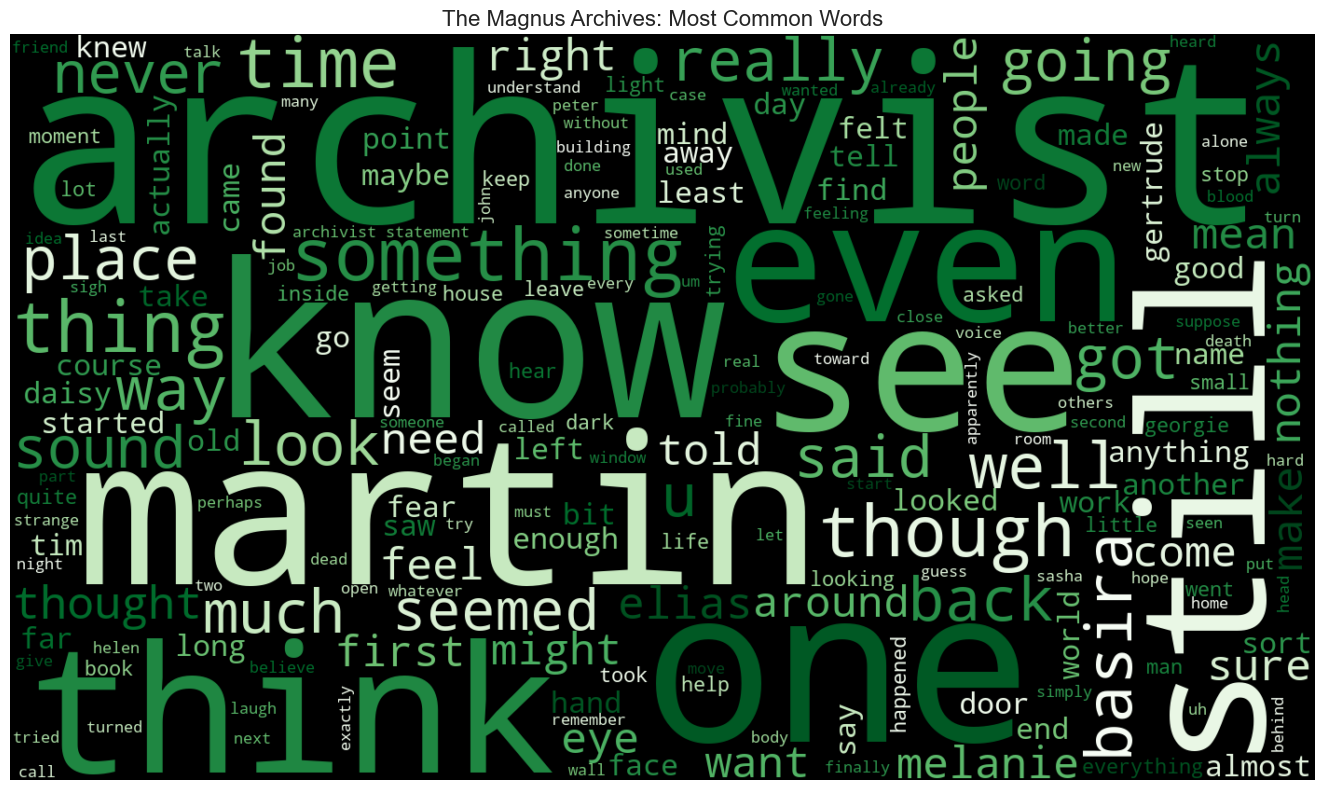

In [87]:
fig, ax = plt.subplots(figsize=(14, 8))
wordcloud_obj = WordCloud(colormap="Greens", width=1400, height=800, background_color='black').generate(" ".join(all_lemmas))
ax.imshow(wordcloud_obj, interpolation='bilinear')
ax.set_title("The Magnus Archives: Most Common Words", fontsize=16)
ax.axis("off")
plt.tight_layout()

plt.show()

## 9. Mentions of the Characters

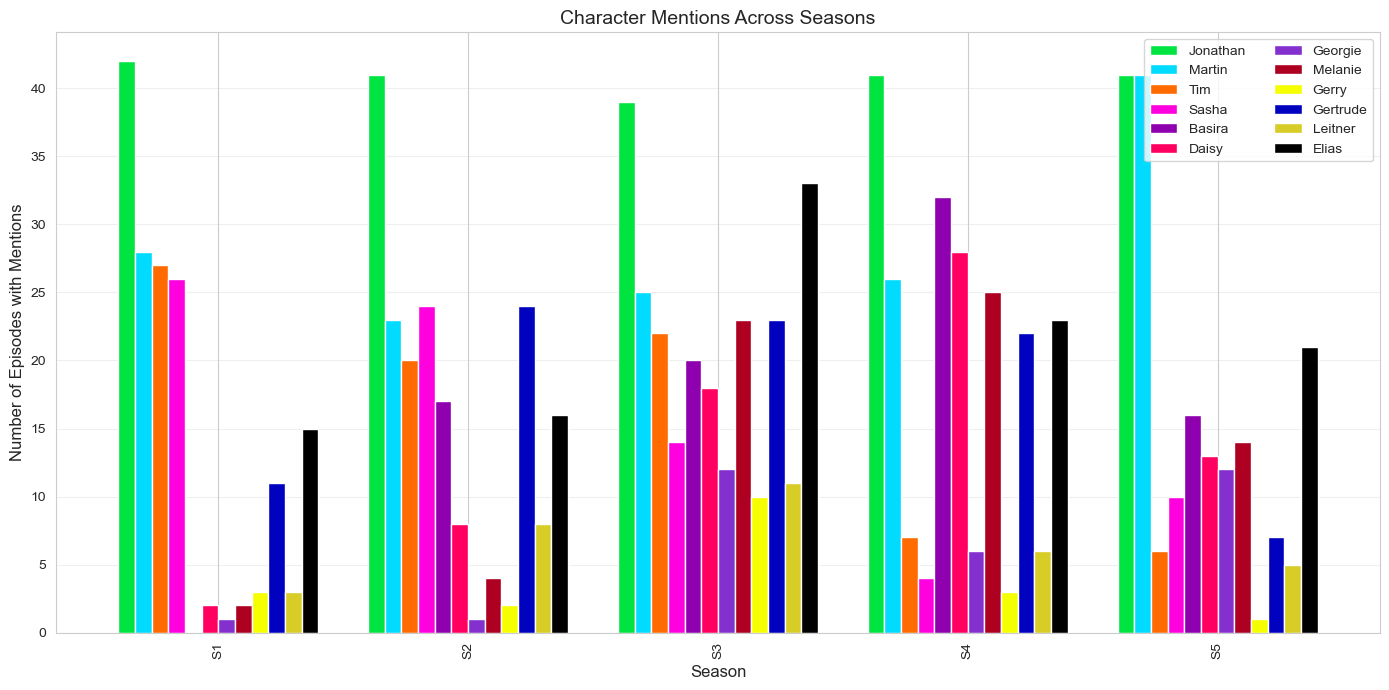

In [90]:
def character_mentions(season, character):
    mentions = []
    for episode in season:
        for name in character:
            if name in season[episode] and episode not in mentions:
                mentions.append(episode)
    return mentions

characters = {
    'Jonathan': ['jon', 'john', 'jonathan', 'sims', 'archivist'],
    'Martin': ['martin', 'blackwood'],
    'Tim': ['tim', 'timothy', 'stoker'],
    'Sasha': ['sasha'],
    'Basira': ['basira', 'hussain'],
    'Daisy': ['daisy', 'alice', 'tonner'],
    'Georgie': ['georgie'],
    'Melanie': ['melanie'],
    'Gerry': ['gerard', 'gerry'],
    'Gertrude': ['gertrude', 'robinson'],
    'Leitner': ['jurgen', 'leitner'],
    'Elias': ['elias', 'bouchard', 'jonah']
}

mentions = {}
for character in characters:
    ch_mentions = []
    for i in range(5):
        ch_mentions.append(len(character_mentions(seasons[i], characters[character])))
    mentions[character] = ch_mentions

# Tim is a special boy for whom the function above doesn't work

tim = []
for i in range(5):
    season = seasons[i]
    tim_mentions = []
    for episode in season:
        data = season[episode]
        data = lemmas(data)
        for name in characters['Tim']:
            if name in data and episode not in tim_mentions:
                tim_mentions.append(episode)
    tim.append(len(tim_mentions))
mentions['Tim'] = tim

# Visualising

character_colors = {
    'Jonathan': '#00e441',   # Green
    'Martin': '#00dbff',     # Cyan
    'Tim': '#ff6b00',        # Orange
    'Sasha': '#ff00df',      # Pink
    'Basira': '#8f00af',     # Purple
    'Daisy': '#ff0060',      # Pinkish Red
    'Georgie': '#8330cf',    # Lavender
    'Melanie': '#ae0021',    # Dark Red
    'Gerry': '#f5ff00',      # Yellow
    'Gertrude': '#0002c0',   # Blue
    'Leitner': '#d8cc27',    # Bad Yellow
    'Elias': '#000000'       # Black
}

fig, ax = plt.subplots(figsize=(14, 7))

char_df = pd.DataFrame(mentions, index=['S1', 'S2', 'S3', 'S4', 'S5'])

# Create bar plot with custom colors
char_df.plot(kind='bar', ax=ax, width=0.8, 
             color=[character_colors[col] for col in char_df.columns])

ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Number of Episodes with Mentions', fontsize=12)
ax.set_title('Character Mentions Across Seasons', fontsize=14)
ax.legend(loc='best', ncol=2)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()

plt.show()